<a href="https://colab.research.google.com/github/FelipeBuitragoC/CAD_Tuberculosis/blob/main/diccionario_CAD_tuberculosis.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# Guía de Términos: CAD Tuberculosis

**Autores:** Santiago Correa Marulanda, Sara Galván Ortega  
**Tutores:** Maria Bernarda Salazar Sánchez, Luis Felipe Buitrago Castro

Este diccionario documenta y ejemplifica las características (*features*) extraídas de radiografías de tórax en el sistema de detección asistida por computador (CAD) para tuberculosis. Cada sección incluye definición, contexto clínico y una visualización computacional sobre la imagen de referencia del repositorio.

> **Imagen de referencia:** `reports/figures/Rx-example.jpg`  

---

## Tabla de Contenidos

| # | Sección |
|---|---------|
| 1 | [Configuración e imagen de referencia](#setup) |
| 2 | [Extracción de Características](#extraccion) |
| 3 | [Características GLCM](#glcm) |
| 3.1 | [Contraste](#contraste) |
| 3.2 | [Disimilitud](#disimilitud) |
| 3.3 | [Homogeneidad](#homogeneidad) |
| 3.4 | [Energía](#energia) |
| 3.5 | [Correlación](#correlacion) |
| 4 | [Características de Forma](#forma) |
| 4.1 | [Perímetro](#perimetro) |
| 4.2 | [Área](#area) |
| 4.3 | [Circularidad](#circularidad) |
| 4.4 | [Extensión](#extension) |
| 4.5 | [Solidez](#solidez) |
| 5 | [Características LBP](#lbp) |
| 6 | [Características Pulmonares](#pulmonar) |
| 7 | [Características DC-GLM](#dcglm) |
| 8 | [Otros Términos Clave](#otros) |
|  | [Referencias](#referencias) |

---

<a id="setup"></a>

## 1. Configuración e imagen de referencia

La siguiente celda instala las dependencias necesarias y carga la imagen desde la ruta del repositorio. **En Colab**, clona el repositorio automáticamente. **En local**, lee el archivo directamente.


Cargando: https://raw.githubusercontent.com/FelipeBuitragoC/CAD_Tuberculosis/main/reports/figures/Rx-example.jpg
Imagen lista | tamano: (512, 512) | rango: [0.000, 0.959]


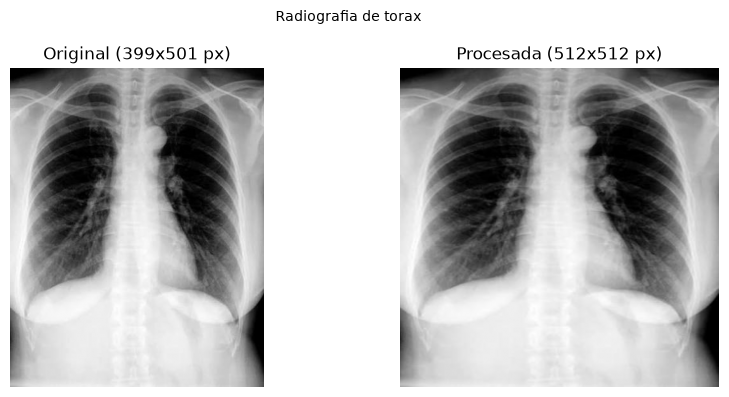

In [3]:
import subprocess, sys
for pkg in ["scikit-image", "matplotlib", "numpy", "scipy", "pillow"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage import img_as_ubyte, img_as_float
from skimage.transform import resize
from PIL import Image
import urllib.request, io

# URL raw del repositorio público 
IMG_URL = "https://raw.githubusercontent.com/FelipeBuitragoC/CAD_Tuberculosis/main/reports/figures/Rx-example.jpg"

print(f"Cargando: {IMG_URL}")
with urllib.request.urlopen(IMG_URL) as r:
    img_raw = np.array(Image.open(io.BytesIO(r.read())).convert("L"))

TARGET    = 512
img       = img_as_float(img_raw)
img       = resize(img, (TARGET, TARGET), anti_aliasing=True)
img_uint8 = img_as_ubyte(img)

print(f"Imagen lista | tamano: {img.shape} | rango: [{img.min():.3f}, {img.max():.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(img_raw, cmap="gray")
axes[0].set_title(f"Original ({img_raw.shape[1]}x{img_raw.shape[0]} px)")
axes[0].axis("off")
axes[1].imshow(img, cmap="gray")
axes[1].set_title(f"Procesada ({TARGET}x{TARGET} px)")
axes[1].axis("off")
fig.suptitle("Radiografia de torax", fontsize=10)
plt.tight_layout()
plt.show()


<a id="extraccion"></a>

## 2. Extracción de Características

> Es el proceso mediante el cual se transforma información compleja, como una imagen, en un conjunto de variables numéricas que contienen propiedades consideradas relevantes para el problema.

La extracción de características es una fase crucial en la clasificación de enfermedades respiratorias, ya que permite identificar patrones y rasgos asociados a afecciones específicas. Consiste en obtener información de alto nivel a partir de imágenes —como el color, la forma y la textura— asegurando que solo se consideren las áreas relevantes para el análisis (Tonni et al., 2025).

```
Radiografía  →  Preprocesamiento  →  Extracción  →  Vector de características  →  Clasificador  →  Diagnóstico
```

[Volver a la Tabla de Contenidos](#toc)

---

<a id="glcm"></a>

## 3. Características GLCM
### *Gray-Level Co-Occurrence Matrix*

La GLCM es un modelo estadístico que considera las conexiones espaciales entre píxeles, capturando información textural significativa sobre la distribución espacial de las intensidades y permitiendo la caracterización de los patrones de los tejidos (Tonni et al., 2025; Prince et al., 2025). Las enfermedades respiratorias presentan patrones de textura distintivos, y el uso de descriptores GLCM ayuda a capturar su complejidad.

[Volver a la Tabla de Contenidos](#toc)

---

In [4]:
from skimage.feature import graycomatrix, graycoprops

# GLCM con distancia 1, cuatro ángulos
glcm = graycomatrix(img_uint8, distances=[1],
                    angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                    levels=256, symmetric=True, normed=True)

contrast      = graycoprops(glcm, "contrast").mean()
dissimilarity = graycoprops(glcm, "dissimilarity").mean()
homogeneity   = graycoprops(glcm, "homogeneity").mean()
energy        = graycoprops(glcm, "energy").mean()
correlation   = graycoprops(glcm, "correlation").mean()

print("Características GLCM (promedio sobre 4 ángulos):")
print(f"  Contraste:     {contrast:.4f}")
print(f"  Disimilitud:   {dissimilarity:.4f}")
print(f"  Homogeneidad:  {homogeneity:.4f}")
print(f"  Energía:       {energy:.4f}")
print(f"  Correlación:   {correlation:.4f}")

# Función auxiliar: mapa de propiedad GLCM en ventanas deslizantes
def glcm_map(image, prop, win=48, step=24):
    rows = list(range(0, image.shape[0] - win, step))
    cols = list(range(0, image.shape[1] - win, step))
    out  = np.zeros((len(rows), len(cols)))
    for i, r in enumerate(rows):
        for j, c in enumerate(cols):
            patch = image[r:r+win, c:c+win]
            g = graycomatrix(patch, [1], [0, np.pi/2], 256, symmetric=True, normed=True)
            out[i, j] = graycoprops(g, prop).mean()
    return out


Características GLCM (promedio sobre 4 ángulos):
  Contraste:     18.5396
  Disimilitud:   2.6212
  Homogeneidad:  0.4233
  Energía:       0.0358
  Correlación:   0.9983


<a id="contraste"></a>

### 3.1 Contraste (*Contrast*)

El contraste cuantifica cuánto difieren las intensidades entre los píxeles de referencia y sus vecinos. Valores más altos indican variaciones significativas dentro de la GLCM y señalan posibles anomalías en el tejido pulmonar (Tonni et al., 2025).

**Fórmula:** `contraste = Σ (i−j)² · P(i,j)`

[Volver a la Tabla de Contenidos](#toc)

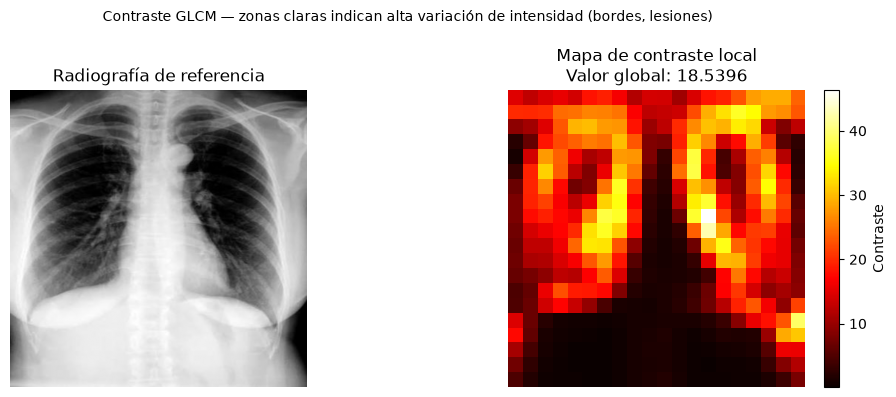

In [5]:
cont_map = glcm_map(img_uint8, "contrast")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Radiografía de referencia")
axes[0].axis("off")
im = axes[1].imshow(cont_map, cmap="hot", interpolation="nearest")
axes[1].set_title(f"Mapa de contraste local\nValor global: {contrast:.4f}")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Contraste")
fig.suptitle("Contraste GLCM — zonas claras indican alta variación de intensidad (bordes, lesiones)", fontsize=10)
plt.tight_layout(); plt.show()


<a id="disimilitud"></a>

### 3.2 Disimilitud (*Dissimilarity*)

Cuantifica la diferencia absoluta entre los niveles de gris de pares de píxeles. A diferencia del contraste, usa la diferencia absoluta en lugar de elevarla al cuadrado, lo que la hace menos sensible a diferencias extremas.

**Fórmula:** `disimilitud = Σ |i−j| · P(i,j)`

[Volver a la Tabla de Contenidos](#toc)

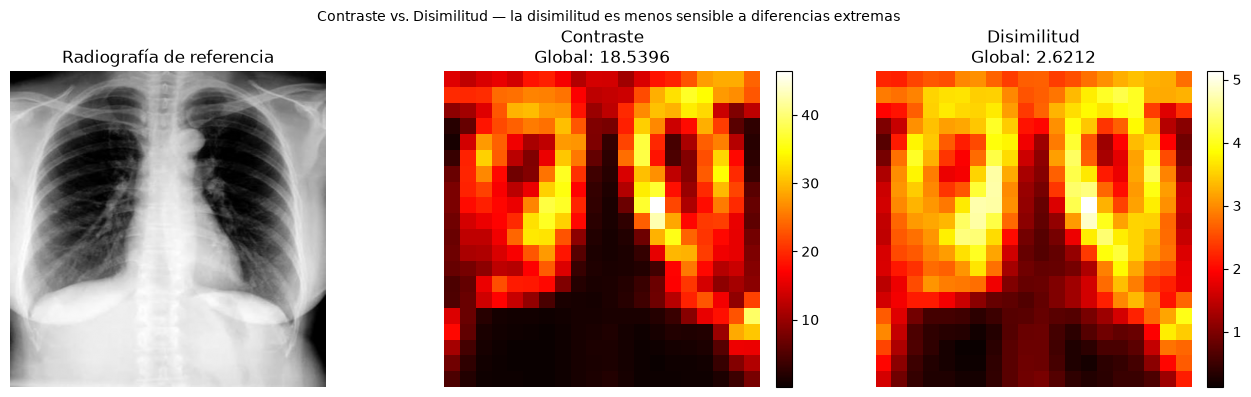

In [6]:
diss_map = glcm_map(img_uint8, "dissimilarity")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Radiografía de referencia")
axes[0].axis("off")
im1 = axes[1].imshow(cont_map, cmap="hot", interpolation="nearest")
axes[1].set_title(f"Contraste\nGlobal: {contrast:.4f}")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
im2 = axes[2].imshow(diss_map, cmap="hot", interpolation="nearest")
axes[2].set_title(f"Disimilitud\nGlobal: {dissimilarity:.4f}")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
fig.suptitle("Contraste vs. Disimilitud — la disimilitud es menos sensible a diferencias extremas", fontsize=10)
plt.tight_layout(); plt.show()


<a id="homogeneidad"></a>

### 3.3 Homogeneidad (*Homogeneity*)

Indica qué tan concentrados están los elementos de la GLCM alrededor de su diagonal. Una mayor homogeneidad significa que los niveles de gris de los píxeles relacionados tienden a ser similares (Prince et al., 2025). Los pulmones sanos muestran valores de homogeneidad más altos, indicando uniformidad de textura (Tonni et al., 2025).

**Fórmula:** `homogeneidad = Σ P(i,j) / (1 + |i−j|)`

[Volver a la Tabla de Contenidos](#toc)

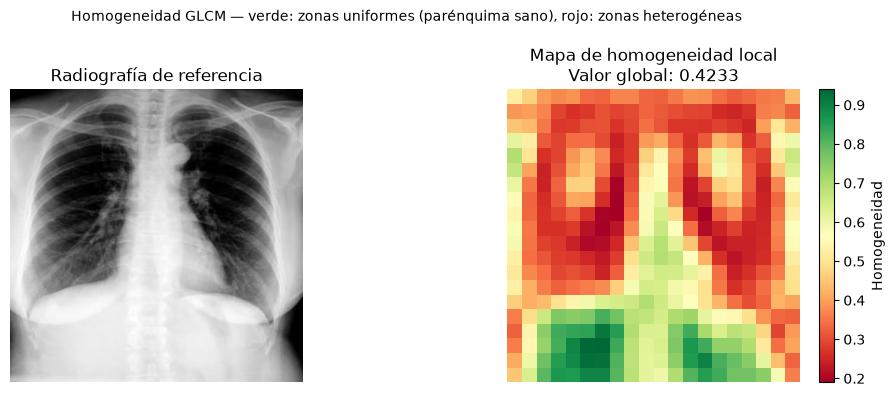

In [7]:
hom_map = glcm_map(img_uint8, "homogeneity")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Radiografía de referencia")
axes[0].axis("off")
im = axes[1].imshow(hom_map, cmap="RdYlGn", interpolation="nearest")
axes[1].set_title(f"Mapa de homogeneidad local\nValor global: {homogeneity:.4f}")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Homogeneidad")
fig.suptitle("Homogeneidad GLCM — verde: zonas uniformes (parénquima sano), rojo: zonas heterogéneas", fontsize=10)
plt.tight_layout(); plt.show()


<a id="energia"></a>

### 3.4 Energía (*Energy*)

Cuantifica la uniformidad local de los niveles de gris; valores más altos indican mayor similitud entre píxeles. Los pulmones sanos exhiben valores de energía más altos que las regiones patológicas (Tonni et al., 2025). Es equivalente al Momento Angular Secundario (ASM).

**Fórmula:** `energía = Σ P(i,j)²`

[Volver a la Tabla de Contenidos](#toc)

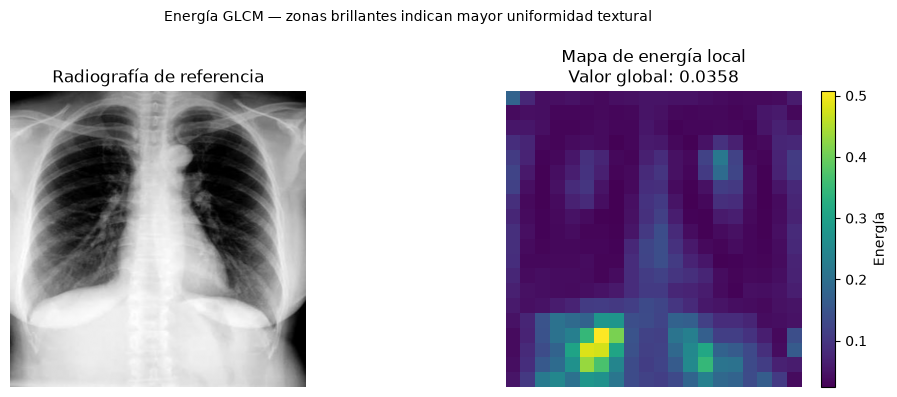

In [8]:
energy_map = glcm_map(img_uint8, "energy")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Radiografía de referencia")
axes[0].axis("off")
im = axes[1].imshow(energy_map, cmap="viridis", interpolation="nearest")
axes[1].set_title(f"Mapa de energía local\nValor global: {energy:.4f}")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Energía")
fig.suptitle("Energía GLCM — zonas brillantes indican mayor uniformidad textural", fontsize=10)
plt.tight_layout(); plt.show()


<a id="correlacion"></a>

### 3.5 Correlación (*Correlation*)

Indica la relación lineal entre los valores de los niveles de gris dentro de la GLCM. Mide en qué medida el valor de intensidad de un píxel puede predecirse linealmente a partir de su vecino. Valores cercanos a 1 indican alta predictibilidad lineal de la textura.

[Volver a la Tabla de Contenidos](#toc)

---

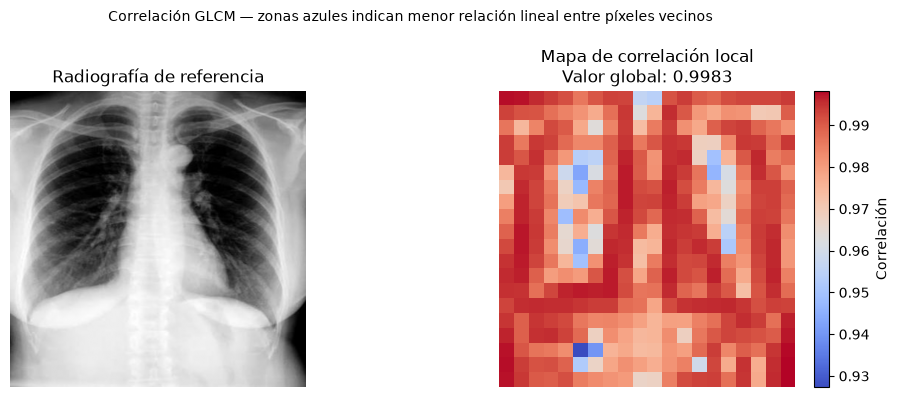

In [9]:
corr_map = glcm_map(img_uint8, "correlation")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Radiografía de referencia")
axes[0].axis("off")
im = axes[1].imshow(corr_map, cmap="coolwarm", interpolation="nearest")
axes[1].set_title(f"Mapa de correlación local\nValor global: {correlation:.4f}")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Correlación")
fig.suptitle("Correlación GLCM — zonas azules indican menor relación lineal entre píxeles vecinos", fontsize=10)
plt.tight_layout(); plt.show()


<a id="forma"></a>

## 4. Características Basadas en la Forma
### *Shape-based Features*

Las características basadas en la forma son cruciales para identificar enfermedades respiratorias a través de imágenes de rayos X, ya que capturan características geométricas esenciales para la clasificación de enfermedades (Ayaz et al., 2021). Tonni et al. (2025) identifican seis características basadas en la forma —perímetro, área, circularidad, extensión, solidez y área rectangular— que son cruciales para identificar lesiones pulmonares irregulares.

[Volver a la Tabla de Contenidos](#toc)

In [21]:
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects, remove_small_holes
from skimage.segmentation import find_boundaries

# Segmentar regiones de alta densidad (posibles lesiones / estructuras densas)
thresh  = threshold_otsu(img)
binary  = img > thresh * 1.05
binary  = remove_small_objects(binary, min_size=80)
binary  = remove_small_holes(binary, area_threshold=200)
labeled = label(binary)
regions = regionprops(labeled, intensity_image=img)

# Seleccionar la región más representativa (excluyendo estructuras muy grandes como mediastino)
candidates = [r for r in regions if 80 < r.area < img.size * 0.08]
if candidates:
    lesion = max(candidates, key=lambda r: r.mean_intensity * r.solidity)
else:
    lesion = max(regions, key=lambda r: r.area)

minr, minc, maxr, maxc = lesion.bbox
pad = 30
r0 = max(0, minr - pad); r1 = min(img.shape[0], maxr + pad)
c0 = max(0, minc - pad); c1 = min(img.shape[1], maxc + pad)
lesion_mask = labeled == lesion.label

circ = 4 * np.pi * lesion.area / lesion.perimeter**2

print(f"Región seleccionada para características de forma:")
print(f"  Área:          {lesion.area} px")
print(f"  Perímetro:     {lesion.perimeter:.1f} px")
print(f"  Circularidad:  {circ:.4f}")
print(f"  Extensión:     {lesion.extent:.4f}")
print(f"  Solidez:       {lesion.solidity:.4f}")
print(f"  Centroide:     ({lesion.centroid[0]:.1f}, {lesion.centroid[1]:.1f})")


Región seleccionada para características de forma:
  Área:          159873.0 px
  Perímetro:     4562.1 px
  Circularidad:  0.0965
  Extensión:     0.6099
  Solidez:       0.6361
  Centroide:     (305.0, 253.5)


<a id="perimetro"></a>

### 4.1 Perímetro (*Perimeter*)

El perímetro de una lesión pulmonar indica su extensión. Un perímetro aumentado indica la presencia de una infección (Tonni et al., 2025).

[Volver a la Tabla de Contenidos](#toc)

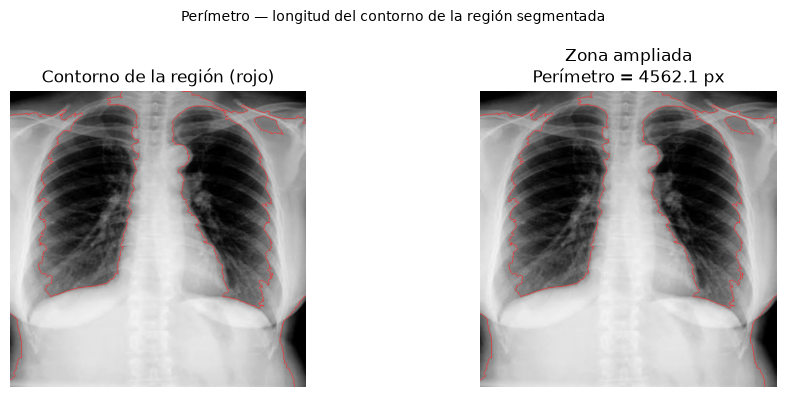

In [11]:
contour_mask = find_boundaries(lesion_mask, mode="outer")
overlay = np.stack([img, img, img], axis=-1)
overlay[contour_mask] = [1.0, 0.15, 0.15]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(overlay)
axes[0].set_title("Contorno de la región (rojo)")
axes[0].axis("off")
axes[1].imshow(overlay[r0:r1, c0:c1])
axes[1].set_title(f"Zona ampliada\nPerímetro = {lesion.perimeter:.1f} px")
axes[1].axis("off")
fig.suptitle("Perímetro — longitud del contorno de la región segmentada", fontsize=10)
plt.tight_layout(); plt.show()


<a id="area"></a>

### 4.2 Área (*Area*)

La métrica del área mide el tamaño de una región pulmonar a partir del número de píxeles dentro de un contorno específico (Tonni et al., 2025). Lesiones con mayor área indican una afectación más extensa del parénquima pulmonar.

[Volver a la Tabla de Contenidos](#toc)

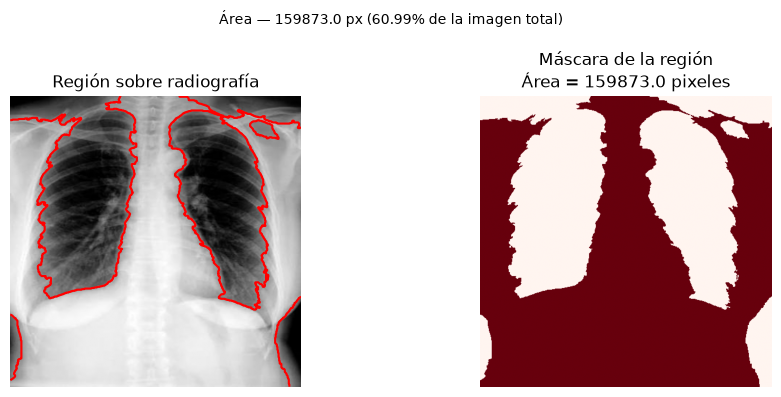

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img, cmap="gray")
axes[0].contour(lesion_mask, colors="red", linewidths=1.5)
axes[0].set_title("Región sobre radiografía")
axes[0].axis("off")
axes[1].imshow(lesion_mask[r0:r1, c0:c1], cmap="Reds")
axes[1].set_title(f"Máscara de la región\nÁrea = {lesion.area} pixeles")
axes[1].axis("off")
fig.suptitle(f"Área — {lesion.area} px ({lesion.area/img.size*100:.2f}% de la imagen total)", fontsize=10)
plt.tight_layout(); plt.show()


<a id="circularidad"></a>

### 4.3 Circularidad (*Circularity*)

La circularidad mide la redondez del área lesionada, indicando anomalías en el pulmón (Tonni et al., 2025). Un círculo perfecto tiene circularidad = 1; valores más bajos indican formas más irregulares, características de lesiones necróticas o cavitadas.

**Fórmula:** `circularidad = 4π · Area / Perímetro²`

[Volver a la Tabla de Contenidos](#toc)

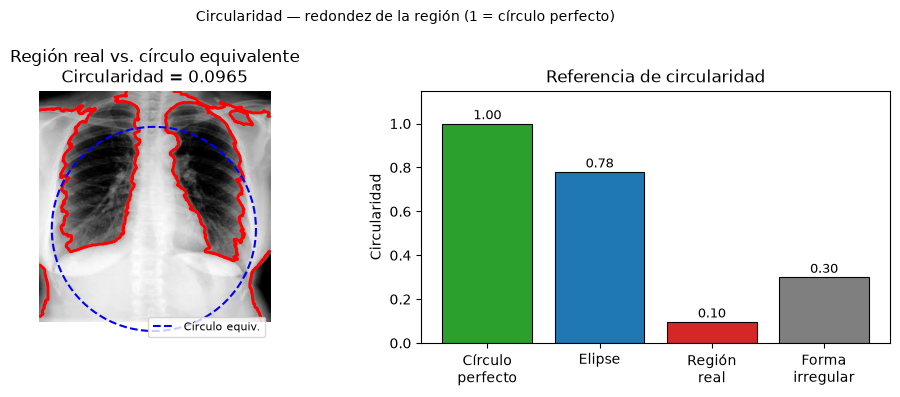

In [23]:
r_equiv = np.sqrt(lesion.area / np.pi)
theta   = np.linspace(0, 2*np.pi, 300)
cx, cy  = lesion.centroid[1] - c0, lesion.centroid[0] - r0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img[r0:r1, c0:c1], cmap="gray")
axes[0].contour(lesion_mask[r0:r1, c0:c1], colors="red", linewidths=2)
axes[0].plot(cx + r_equiv*np.cos(theta), cy + r_equiv*np.sin(theta),
             "b--", lw=1.5, label="Círculo equiv.")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].set_title(f"Región real vs. círculo equivalente\nCircularidad = {circ:.4f}")
axes[0].axis("off")

shapes = ["Círculo\nperfecto", "Elipse", "Región\nreal", "Forma\nirregular"]
vals   = [1.0, 0.78, circ, 0.30]
colors_b = ["#2ca02c", "#1f77b4", "#d62728", "#7f7f7f"]
bars = axes[1].bar(shapes, vals, color=colors_b, edgecolor="black", linewidth=0.8)
axes[1].set_ylim(0, 1.15); axes[1].set_ylabel("Circularidad")
axes[1].set_title("Referencia de circularidad")
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
fig.suptitle("Circularidad — redondez de la región (1 = círculo perfecto)", fontsize=10)
plt.tight_layout(); plt.show()


<a id="extension"></a>

### 4.4 Extensión (*Extent*)

La extensión captura la distribución espacial de las anomalías pulmonares al resaltar bordes, curvas y extremos (Tonni et al., 2025). Se calcula como la razón entre el área de la región y el área de su bounding box.

**Fórmula:** `extensión = Area / (alto_bbox × ancho_bbox)`

[Volver a la Tabla de Contenidos](#toc)

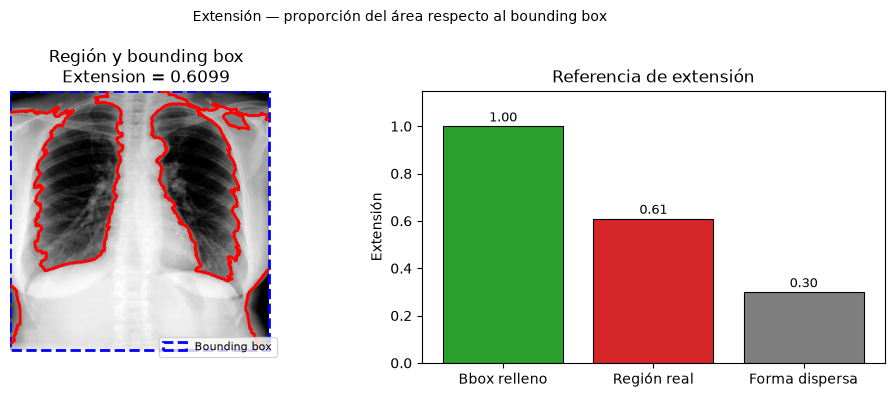

In [24]:
bbox_h = maxr - minr
bbox_w = maxc - minc

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
zoom_img  = img[r0:r1, c0:c1]
zoom_mask = lesion_mask[r0:r1, c0:c1]
axes[0].imshow(zoom_img, cmap="gray")
axes[0].contour(zoom_mask, colors="red", linewidths=2)
rect = mpatches.Rectangle((minc-c0, minr-r0), bbox_w, bbox_h,
                           linewidth=2, edgecolor="blue", facecolor="none",
                           linestyle="--", label="Bounding box")
axes[0].add_patch(rect)
axes[0].legend(fontsize=8, loc="lower right")
axes[0].set_title(f"Región y bounding box\nExtension = {lesion.extent:.4f}")
axes[0].axis("off")

shapes_e = ["Bbox relleno", "Región real", "Forma dispersa"]
vals_e   = [1.0, lesion.extent, 0.30]
colors_e = ["#2ca02c", "#d62728", "#7f7f7f"]
bars2 = axes[1].bar(shapes_e, vals_e, color=colors_e, edgecolor="black", linewidth=0.8)
axes[1].set_ylim(0, 1.15); axes[1].set_ylabel("Extensión")
axes[1].set_title("Referencia de extensión")
for bar, v in zip(bars2, vals_e):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
fig.suptitle("Extensión — proporción del área respecto al bounding box", fontsize=10)
plt.tight_layout(); plt.show()


<a id="solidez"></a>

### 4.5 Solidez (*Solidity*)

La solidez representa la compacidad de una lesión pulmonar, calculada dividiendo el área de la lesión por el área de su superficie convexa (Tonni et al., 2025). Una solidez baja indica concavidades o bordes irregulares, característicos de lesiones necróticas o cavitadas en tuberculosis.

**Fórmula:** `solidez = Area / Area_casco_convexo`

[Volver a la Tabla de Contenidos](#toc)

---

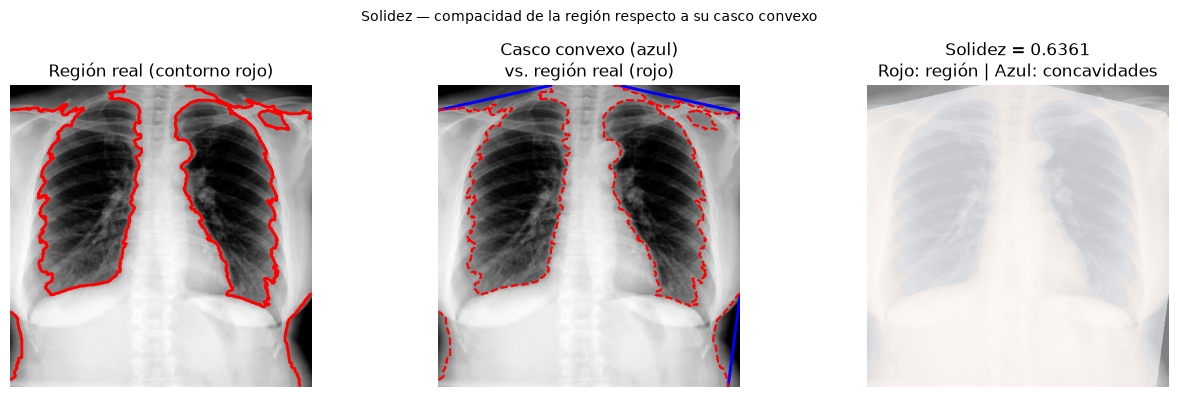

Solidez: 0.6361  (1.0 = perfectamente convexa, sin concavidades)


In [25]:
from skimage.morphology import convex_hull_image

convex_mask = convex_hull_image(lesion_mask)
diff_mask   = convex_mask[r0:r1, c0:c1].astype(int) - zoom_mask.astype(int)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(zoom_img, cmap="gray")
axes[0].contour(zoom_mask, colors="red", linewidths=2)
axes[0].set_title("Región real (contorno rojo)")
axes[0].axis("off")

axes[1].imshow(zoom_img, cmap="gray")
axes[1].contour(convex_mask[r0:r1, c0:c1], colors="blue", linewidths=2)
axes[1].contour(zoom_mask, colors="red", linewidths=1.5, linestyles="--")
axes[1].set_title("Casco convexo (azul)\nvs. región real (rojo)")
axes[1].axis("off")

axes[2].imshow(zoom_img, cmap="gray", alpha=0.5)
axes[2].imshow(np.ma.masked_where(zoom_mask == 0, zoom_mask), cmap="Reds", alpha=0.6)
axes[2].imshow(np.ma.masked_where(diff_mask == 0, diff_mask), cmap="Blues", alpha=0.6)
axes[2].set_title(f"Solidez = {lesion.solidity:.4f}\nRojo: región | Azul: concavidades")
axes[2].axis("off")

fig.suptitle("Solidez — compacidad de la región respecto a su casco convexo", fontsize=10)
plt.tight_layout(); plt.show()
print(f"Solidez: {lesion.solidity:.4f}  (1.0 = perfectamente convexa, sin concavidades)")


<a id="lbp"></a>

## 5. Características LBP
### *Local Binary Pattern*

El LBP es un modelo estadístico eficiente para extraer características de imágenes. Los valores LBP se obtienen binarizando las diferencias entre píxeles adyacentes, reorganizándolos y aplicando una función escalón para obtener la representación binaria de las variaciones locales. El operador LBP provee una representación compacta de la textura local al codificar las relaciones espaciales entre píxeles de un vecindario.

Las características LBP son: **ConvexArea**, **lbp_energy** y **lbp_entropy**.

[Volver a la Tabla de Contenidos](#toc)

c:\Users\bernarda.salazar\AppData\Local\anaconda3\Lib\site-packages\skimage\feature\texture.py:360: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Caracteristicas LBP (radio=3, puntos=24):
  ConvexArea:   261617 px
  lbp_energy:   0.077998
  lbp_entropy:  2.8793


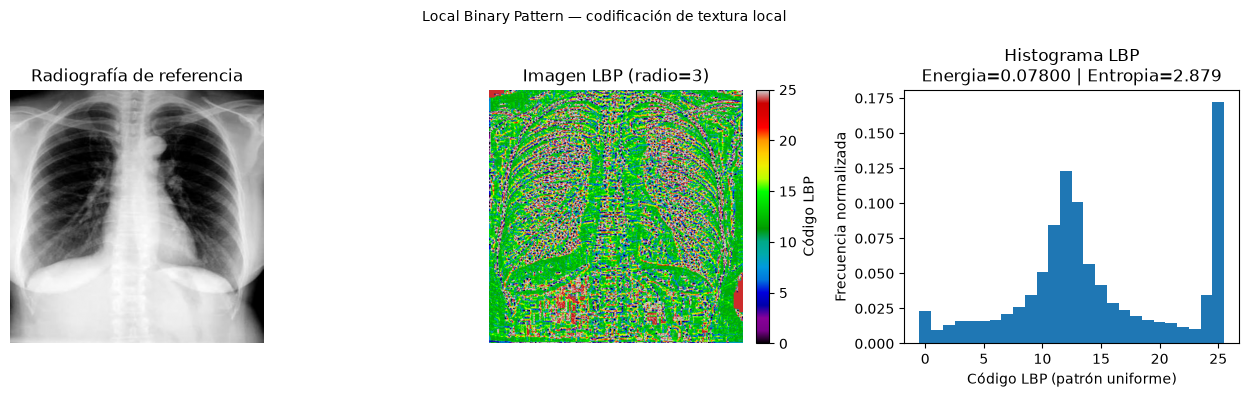

In [26]:
from skimage.feature import local_binary_pattern
from scipy.stats import entropy as sp_entropy

radius   = 3
n_points = 8 * radius
lbp_img  = local_binary_pattern(img, n_points, radius, method="uniform")

n_bins = int(lbp_img.max() + 1)
hist, _ = np.histogram(lbp_img, density=True, bins=n_bins, range=(0, n_bins))

lbp_energy_val  = float(np.sum(hist**2))
lbp_entropy_val = float(sp_entropy(hist + 1e-10))

lbp_binary = lbp_img > np.median(lbp_img)
from skimage.morphology import convex_hull_image as chi
lbp_convex   = chi(lbp_binary)
convex_area  = int(lbp_convex.sum())

print(f"Caracteristicas LBP (radio={radius}, puntos={n_points}):")
print(f"  ConvexArea:   {convex_area} px")
print(f"  lbp_energy:   {lbp_energy_val:.6f}")
print(f"  lbp_entropy:  {lbp_entropy_val:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Radiografía de referencia")
axes[0].axis("off")
im_lbp = axes[1].imshow(lbp_img, cmap="nipy_spectral")
axes[1].set_title(f"Imagen LBP (radio={radius})")
axes[1].axis("off")
plt.colorbar(im_lbp, ax=axes[1], fraction=0.046, pad=0.04, label="Código LBP")
axes[2].bar(range(len(hist)), hist, color="#1f77b4", edgecolor="none", width=1)
axes[2].set_xlabel("Código LBP (patrón uniforme)")
axes[2].set_ylabel("Frecuencia normalizada")
axes[2].set_title(f"Histograma LBP\nEnergia={lbp_energy_val:.5f} | Entropia={lbp_entropy_val:.3f}")
fig.suptitle("Local Binary Pattern — codificación de textura local", fontsize=10)
plt.tight_layout(); plt.show()


<a id="pulmonar"></a>

## 6. Características Pulmonares
### *Lung Features*

Los profesionales médicos evalúan la densidad pulmonar anormal comparando las zonas superior, media e inferior de ambos pulmones. Se calcula la blancura anormal —mayor densidad— o la negrura anormal —menor densidad— utilizando los niveles de intensidad de la imagen. Se extraen la densidad media, la densidad estándar, el volumen pulmonar y los puntos clave SIFT (Tonni et al., 2025).

[Volver a la Tabla de Contenidos](#toc)

  Izq. Superior       densidad media=0.3538 | std=0.2441 | volumen aereo=22143 px
  Izq. Medio          densidad media=0.4339 | std=0.2542 | volumen aereo=17055 px
  Izq. Inferior       densidad media=0.8376 | std=0.1121 | volumen aereo=525 px
  Der. Superior       densidad media=0.3577 | std=0.2444 | volumen aereo=20460 px
  Der. Medio          densidad media=0.4875 | std=0.2876 | volumen aereo=12825 px
  Der. Inferior       densidad media=0.7561 | std=0.1687 | volumen aereo=2383 px

Puntos clave SIFT detectados: 248


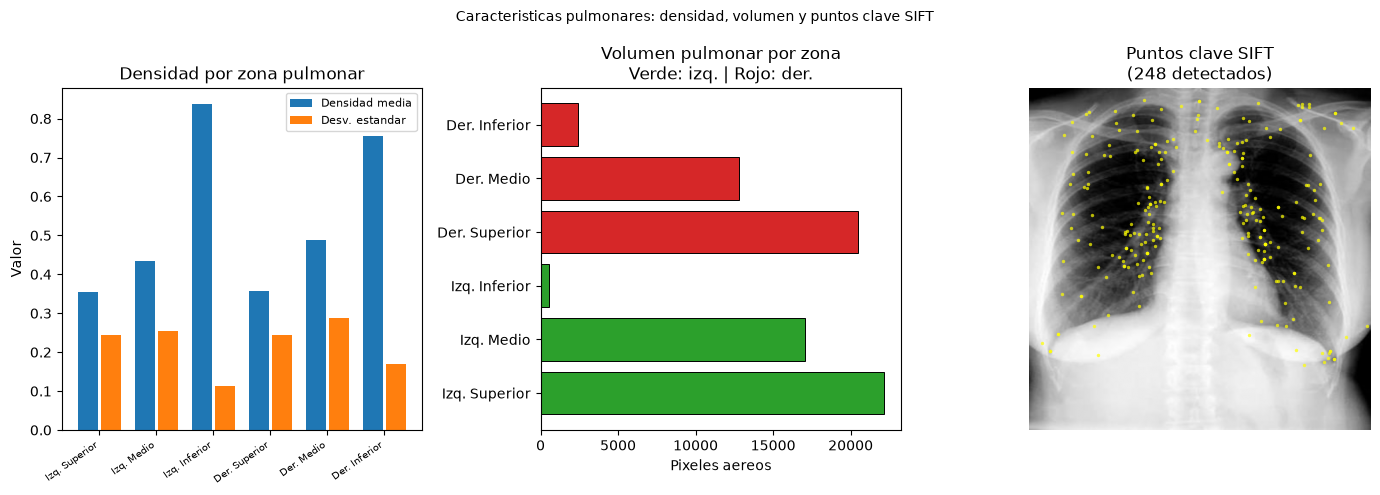

In [17]:
from skimage.feature import SIFT

H, W = img.shape
# Dividir la imagen en seis zonas (superior/media/inferior x izq/der)
zones = {
    "Izq. Superior":  img[int(H*0.05):int(H*0.38), int(W*0.05):int(W*0.45)],
    "Izq. Medio":     img[int(H*0.38):int(H*0.65), int(W*0.05):int(W*0.45)],
    "Izq. Inferior":  img[int(H*0.65):int(H*0.90), int(W*0.05):int(W*0.45)],
    "Der. Superior":  img[int(H*0.05):int(H*0.38), int(W*0.55):int(W*0.95)],
    "Der. Medio":     img[int(H*0.38):int(H*0.65), int(W*0.55):int(W*0.95)],
    "Der. Inferior":  img[int(H*0.65):int(H*0.90), int(W*0.55):int(W*0.95)],
}

stats = {}
for name, roi in zones.items():
    stats[name] = {
        "mean":   float(roi.mean()),
        "std":    float(roi.std()),
        "volume": int((roi < 0.45).sum()),   # pixeles aereos (baja densidad)
    }
    print(f"  {name:18s}  densidad media={stats[name]['mean']:.4f} | "
          f"std={stats[name]['std']:.4f} | volumen aereo={stats[name]['volume']} px")

# SIFT
detector = SIFT()
detector.detect_and_extract(img)
kp = detector.keypoints
print(f"\nPuntos clave SIFT detectados: {len(kp)}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Densidad media por zona
names_z = list(stats.keys())
means_z = [stats[z]["mean"] for z in names_z]
stds_z  = [stats[z]["std"]  for z in names_z]
x = np.arange(len(names_z))
axes[0].bar(x - 0.2, means_z, 0.35, label="Densidad media", color="#1f77b4")
axes[0].bar(x + 0.2, stds_z,  0.35, label="Desv. estandar",  color="#ff7f0e")
axes[0].set_xticks(x); axes[0].set_xticklabels(names_z, rotation=35, ha="right", fontsize=7)
axes[0].set_ylabel("Valor"); axes[0].set_title("Densidad por zona pulmonar"); axes[0].legend(fontsize=8)

# Volumen aéreo por zona
vols = [stats[z]["volume"] for z in names_z]
colors_v = ["#2ca02c"]*3 + ["#d62728"]*3
axes[1].barh(names_z, vols, color=colors_v, edgecolor="black", linewidth=0.7)
axes[1].set_xlabel("Pixeles aereos"); axes[1].set_title("Volumen pulmonar por zona\nVerde: izq. | Rojo: der.")

# Puntos SIFT sobre la imagen
axes[2].imshow(img, cmap="gray")
axes[2].scatter(kp[:, 1], kp[:, 0], s=6, c="yellow", alpha=0.7, linewidths=0)
axes[2].set_title(f"Puntos clave SIFT\n({len(kp)} detectados)")
axes[2].axis("off")

fig.suptitle("Caracteristicas pulmonares: densidad, volumen y puntos clave SIFT", fontsize=10)
plt.tight_layout(); plt.show()


<a id="dcglm"></a>

## 7. Características DC-GLM
### *Dynamic Co-Occurrence Grey Level Matrix*

Las características DC-GLM son medidas numéricas obtenidas de una imagen para representar propiedades de su textura, como contraste, homogeneidad, energía o correlación. Convierten información visual en variables de entrada para algoritmos de aprendizaje automático.

### 7.1 Momento Angular Secundario (*Angular Second Moment, ASM*)

El ASM es una medida estadística que caracteriza la uniformidad de una textura; valores elevados indican una distribución de textura más uniforme. Es equivalente a la energía GLCM aplicada en el contexto dinámico del DC-GLM.

**Fórmula:** `ASM = Σ P(i,j)²`

[Volver a la Tabla de Contenidos](#toc)

  Izq. Superior       : ASM = 0.023639
  Izq. Medio          : ASM = 0.020748
  Izq. Inferior       : ASM = 0.119253
  Der. Superior       : ASM = 0.031615
  Der. Medio          : ASM = 0.025693
  Der. Inferior       : ASM = 0.070990


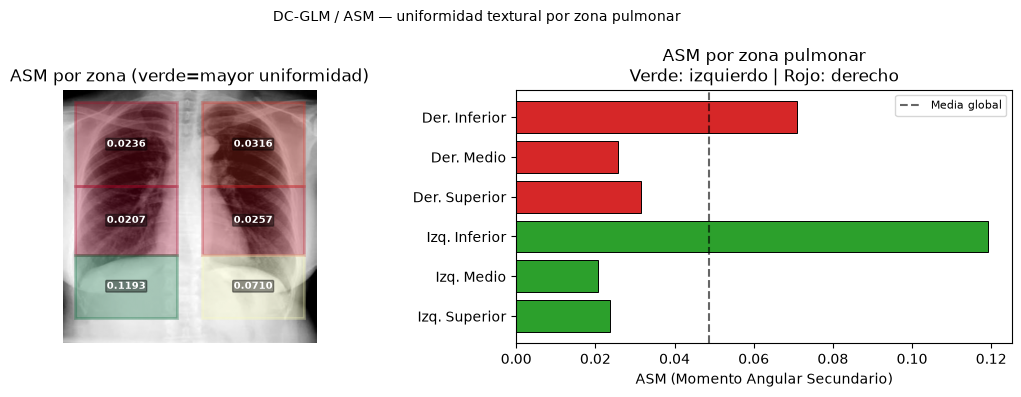

In [18]:
def zone_asm(patch):
    p8 = img_as_ubyte(np.clip(patch, 0, 1))
    if p8.shape[0] < 4 or p8.shape[1] < 4:
        return 0.0
    g = graycomatrix(p8, [1], [0, np.pi/2], 256, symmetric=True, normed=True)
    return float(graycoprops(g, "energy").mean())

asm_vals = {name: zone_asm(roi) for name, roi in zones.items()}
for k, v in asm_vals.items():
    print(f"  {k:20s}: ASM = {v:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img, cmap="gray")

# Dibujar las zonas sobre la imagen
zone_coords = {
    "Izq. Superior": (int(H*0.05), int(W*0.05), int(H*0.38), int(W*0.45)),
    "Izq. Medio":    (int(H*0.38), int(W*0.05), int(H*0.65), int(W*0.45)),
    "Izq. Inferior": (int(H*0.65), int(W*0.05), int(H*0.90), int(W*0.45)),
    "Der. Superior": (int(H*0.05), int(W*0.55), int(H*0.38), int(W*0.95)),
    "Der. Medio":    (int(H*0.38), int(W*0.55), int(H*0.65), int(W*0.95)),
    "Der. Inferior": (int(H*0.65), int(W*0.55), int(H*0.90), int(W*0.95)),
}
cmap_z = plt.cm.RdYlGn
asm_min, asm_max = min(asm_vals.values()), max(asm_vals.values())
for name, (r0z, c0z, r1z, c1z) in zone_coords.items():
    v = asm_vals[name]
    norm_v = (v - asm_min) / (asm_max - asm_min + 1e-10)
    color  = cmap_z(norm_v)
    rect   = mpatches.Rectangle((c0z, r0z), c1z-c0z, r1z-r0z,
                                  linewidth=2, edgecolor=color, facecolor=color, alpha=0.3)
    axes[0].add_patch(rect)
    axes[0].text((c0z+c1z)/2, (r0z+r1z)/2, f"{v:.4f}",
                  ha="center", va="center", fontsize=7, color="white",
                  fontweight="bold", bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.4))
axes[0].set_title("ASM por zona (verde=mayor uniformidad)")
axes[0].axis("off")

colors_asm = ["#2ca02c"]*3 + ["#d62728"]*3
axes[1].barh(list(asm_vals.keys()), list(asm_vals.values()),
             color=colors_asm, edgecolor="black", linewidth=0.7)
axes[1].set_xlabel("ASM (Momento Angular Secundario)")
axes[1].set_title("ASM por zona pulmonar\nVerde: izquierdo | Rojo: derecho")
axes[1].axvline(np.mean(list(asm_vals.values())), color="black",
                linestyle="--", alpha=0.6, label="Media global")
axes[1].legend(fontsize=8)

fig.suptitle("DC-GLM / ASM — uniformidad textural por zona pulmonar", fontsize=10)
plt.tight_layout(); plt.show()


<a id="otros"></a>

## 8. Otros Términos Clave

---

### 8.1 Coocurrencia (*Co-occurrence*)

Concepto estadístico que describe la aparición conjunta de dos valores dentro de una determinada relación espacial en una imagen. Es el principio subyacente de la GLCM.

---

### 8.2 Filtro de Gabor (*Gabor Filter*)

Operador de procesamiento de imágenes diseñado para detectar estructuras con determinadas frecuencias y orientaciones. Combina una función gaussiana con una señal sinusoidal, lo que lo hace especialmente útil para identificar patrones de textura y estructuras orientadas.

---

### 8.3 Filtrado Multiescala (*Multiscale Filtering*)

Estrategia que analiza una imagen utilizando diferentes escalas para detectar simultáneamente estructuras pequeñas, medianas y grandes.

---

### 8.4 Difusión Anisotrópica (*Anisotropic Diffusion*)

Técnica de procesamiento de imágenes para reducir ruido sin eliminar completamente los bordes importantes. La difusión depende de las características locales de la imagen, preservando estructuras relevantes.

---

### 8.5 Difusión Adaptativa Contextual (*Contextual Adaptive Diffusion*)

Método utilizado por CAMSGNeT que controla la difusión de cada región considerando tanto el gradiente de la imagen como la varianza local de las intensidades. Suaviza regiones uniformes y conserva detalles en zonas con estructuras importantes.

---

### 8.6 Gradiente de Imagen (*Image Gradient*)

Representación matemática de cómo cambia la intensidad de una imagen espacialmente. Un gradiente elevado suele indicar una transición fuerte entre regiones, por ejemplo, un borde.

[Volver a la Tabla de Contenidos](#toc)

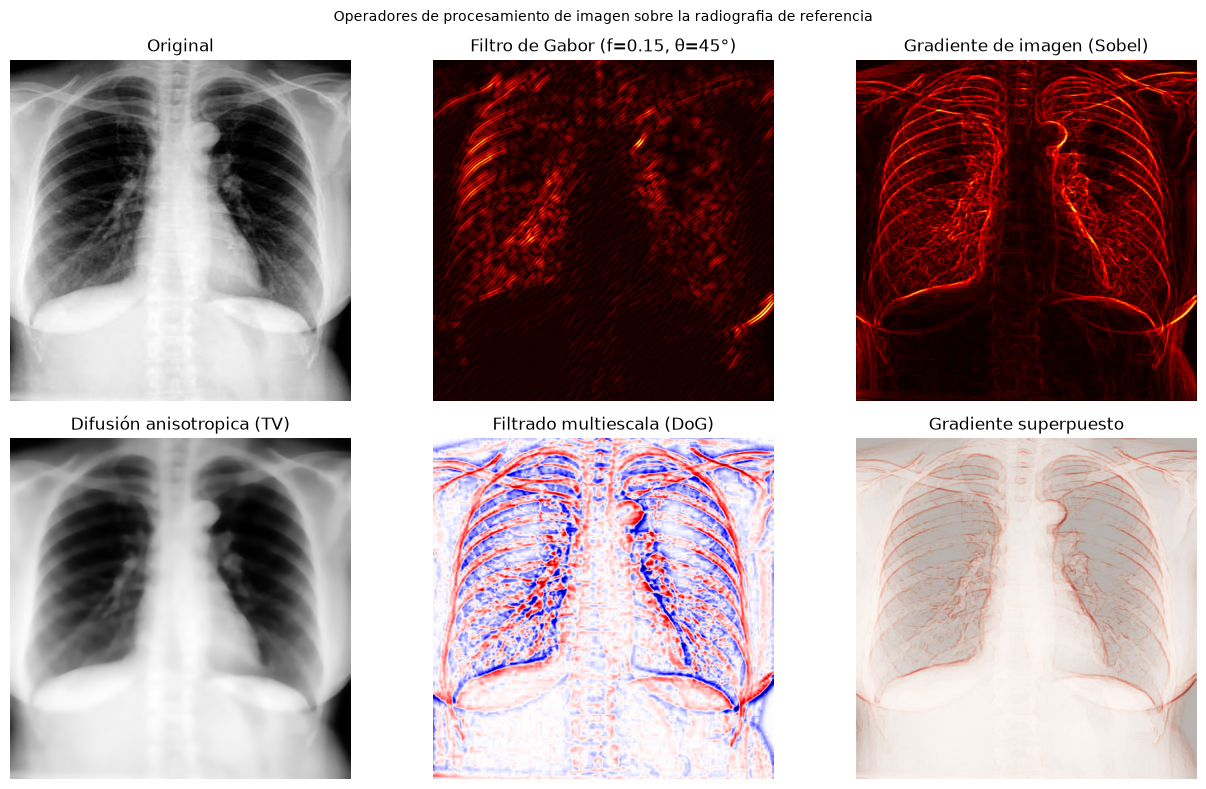

In [27]:
from skimage.filters import gabor, sobel, gaussian as gauss
from skimage.restoration import denoise_tv_chambolle

filt_real, _ = gabor(img, frequency=0.15, theta=np.pi/4)
gradient     = sobel(img)
denoised     = denoise_tv_chambolle(img, weight=0.15)
dog          = gauss(img, sigma=0.5) - gauss(img, sigma=5)   # Diferencia de Gaussianas

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

axes[0,0].imshow(img, cmap="gray")
axes[0,0].set_title("Original"); axes[0,0].axis("off")

axes[0,1].imshow(np.abs(filt_real), cmap="hot")
axes[0,1].set_title("Filtro de Gabor (f=0.15, θ=45°)"); axes[0,1].axis("off")

axes[0,2].imshow(gradient, cmap="hot")
axes[0,2].set_title("Gradiente de imagen (Sobel)"); axes[0,2].axis("off")

axes[1,0].imshow(denoised, cmap="gray")
axes[1,0].set_title("Difusión anisotropica (TV)"); axes[1,0].axis("off")

axes[1,1].imshow(dog, cmap="seismic", vmin=-dog.max(), vmax=dog.max())
axes[1,1].set_title("Filtrado multiescala (DoG)"); axes[1,1].axis("off")

axes[1,2].imshow(img, cmap="gray", alpha=0.6)
axes[1,2].imshow(gradient, cmap="Reds", alpha=0.55)
axes[1,2].set_title("Gradiente superpuesto"); axes[1,2].axis("off")

fig.suptitle("Operadores de procesamiento de imagen sobre la radiografia de referencia", fontsize=10)
plt.tight_layout(); plt.show()


<a id="referencias"></a>

## Referencias

Ayaz, M., Shaukat, F., & Raja, G. (2021). Ensemble learning based automatic detection of tuberculosis in chest X-ray images using hybrid feature descriptors. *Physical and Engineering Sciences in Medicine*, *44*(1), 183–194. https://doi.org/10.1007/s13246-020-00951-x

Prince, R., Niu, Z., Khan, Z. Y., Chambua, J., Yousif, A., Patrick, N., & Batamuliza, J. (2025). Interpretable COVID-19 chest X-ray detection based on handcrafted feature analysis and sequential neural network. *Computers in Biology and Medicine*, *186*, 109659. https://doi.org/10.1016/j.compbiomed.2025.109659

Tonni, T. J., Rony, M. A. H., Fatema, K., Hasan, M. Z., et al. (2025). Framework for enhanced respiratory disease identification with clinical handcrafted features. *Computers in Biology and Medicine*, *195*, 110588. https://doi.org/10.1016/j.compbiomed.2025.110588

---

<p style='text-align:center;color:gray;font-size:.9em'>
Guía de Términos CAD Tuberculosis &nbsp;&middot;&nbsp; Santiago Correa Marulanda &amp; Sara Galván Ortega<br>
Tutores: Maria Bernarda Salazar &nbsp;&middot;&nbsp; Luis Felipe Buitrago Castro
</p>